# Linear Regression

> 📘 **Instructor Curriculum** — M07 Machine Learning, scikit-learn module.

Rough notes. One idea carries the whole file:

```text
y = coefficient * x + intercept
```

School wrote it as `y = mx + c`. Same line, longer names.

| Maths | sklearn | This notebook |
|---|---|---|
| slope `m` | `regressor.coef_` | `86.43` |
| intercept `c` | `regressor.intercept_` | `0.04` |

`fit()` finds those two numbers. `predict()` puts an `x` into that line.

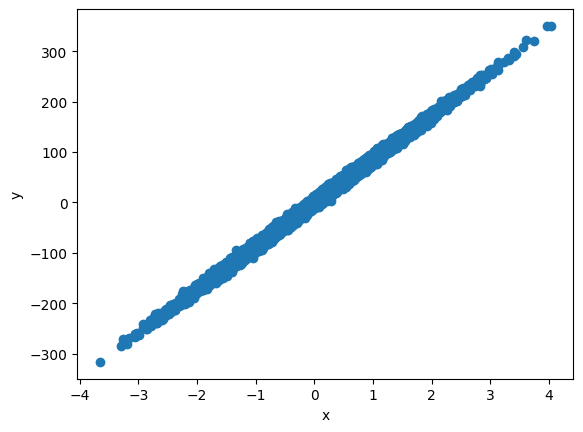

In [1]:
from sklearn.datasets import make_regression
x,y = make_regression(n_features=1, noise=5, n_samples=10000,random_state=1)
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 1. Look at the data first

`make_regression` builds fake data that already *is* a straight line.
`noise=5` scatters the dots a bit so it does not look too perfect.

`n_features=1` means one input column. So `x` has shape `(10000, 1)` — one column,
ten thousand rows.

The plot shows a band of dots going **up to the right**. That is what a positive
coefficient looks like. Our job is to find the one line that sits in the middle of
the band.

## 2. Split before fitting

8000 rows to learn from. 2000 rows kept hidden for the exam.
The model never sees `X_test` while it is learning.

In [2]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=0)


## 3. `fit()` — find the best line

`LinearRegression()` on its own knows nothing. It is an empty box.

`fit(X_train, y_train)` tries lines and keeps the one where the total error is
smallest. Error = the vertical gap between a real dot and the line.

After `fit`, the box holds exactly **two numbers**. 8000 rows went in, 2 floats came
out. The rows are not kept.

```mermaid
flowchart LR
    A["X_train, y_train<br/>8000 rows"] --> B["fit()"]
    B --> C["coef_ = 86.43<br/>intercept_ = 0.04"]
    E["a new x"] --> D["predict()"]
    C --> D
    D --> F["y = 86.43 * x + 0.04"]
    style C fill:#2f6fed,color:#fff
    style F fill:#2f9e6f,color:#fff
```

Anything `fit` learns is stored with a **trailing underscore** — `coef_`, `intercept_`.
No underscore means you typed it in. Underscore means the data taught it.

In [3]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[86.43]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.04227
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[89.35]


## 4. The test input

2000 rows, one column each.

Notice the double brackets — `[[ 1.24445906 ]]`. It is a 2-D array. sklearn always
wants `X` as a table, even when the table has only one column.

In [4]:
X_test

array([[ 1.24445906],
       [ 0.98495167],
       [-1.59370261],
       ...,
       [ 0.24745387],
       [ 0.05529735],
       [ 0.07425068]], shape=(2000, 1))

## 5. `predict()` — run the formula

No learning happens here. For every row it only does:

```text
86.43 * x + 0.04
```

Check the first row by hand: `86.43 * 1.24445906 + 0.04 = 107.6`.
That is exactly the first predicted value.

In [5]:
regressor.predict(X_test)

array([ 107.6063556 ,   85.17598825, -137.70846548, ...,   21.43080311,
          4.82186867,    6.46008839], shape=(2000,))

## 6. `score()` — how good is the line

For a regression model, `score` returns **R²**.

- `1.0` → the line passes through every point.
- `0.0` → the line is no better than always guessing the average of `y`.

We got `0.9966`. The line explains about 99.7% of the movement in `y`. It is this
high only because the data was generated as a straight line. Real data is messier.

In [6]:
regressor.score(X_test,y_test)

0.9966263246017432

## 7. `coef_` — the coefficient (the slope)

**Coefficient = how much `y` moves when `x` goes up by 1.**

Ours is `86.43`. One step right on the x-axis, and the line climbs 86.43 upwards.

```text
        y
        │              ●
        │             /│
        │            / │   rise = 86.43   ← coef_
        │           /  │
        │          ●───┘
        │          run = 1
        └──────────────────── x
```

It comes back as an **array**, not a single number — `array([86.43440685])`.
One entry per input column. We have 1 column, so 1 coefficient. With 5 columns you
would get 5 of them.

The sign tells the direction:

| Sign | Meaning |
|---|---|
| `+` | x goes up, y goes up |
| `−` | x goes up, y goes down |
| near `0` | this column barely matters |

In [7]:
regressor.coef_

array([86.43440685])

## 8. `intercept_` — the starting point

**Intercept = the value of `y` when `x` is 0.** It is where the line crosses the
vertical axis.

Ours is `0.042`, almost zero, because `make_regression` centres its data on the
origin. So our line passes through roughly `(0, 0)`.

It is a plain float, not an array. One line has one starting height.

Short version: **the coefficient tilts the line, the intercept slides it up and
down.** A straight line has only those two knobs.

In [8]:
regressor.intercept_

np.float64(0.042274723015908955)

## 9. Proof — rebuild `predict()` by hand

If `predict()` really is just `m * x + c`, then writing the formula ourselves must
give the same numbers.

In [9]:
import numpy as np

m = regressor.coef_[0]        # the slope        (coefficient)
c = regressor.intercept_      # the height at x=0 (intercept)

by_hand  = m * X_test + c
by_sklearn = regressor.predict(X_test)

print("first 3 by hand   :", by_hand.ravel()[:3])
print("first 3 by sklearn:", by_sklearn[:3])
print("same? ->", np.allclose(by_hand.ravel(), by_sklearn))

first 3 by hand   : [ 107.6063556    85.17598825 -137.70846548]
first 3 by sklearn: [ 107.6063556    85.17598825 -137.70846548]
same? -> True


`True`. There is nothing hidden inside `predict()`. It is one multiply and one add.

## 10. The same two numbers, drawn on the real data

Black dot = the intercept. Green triangle = the coefficient.

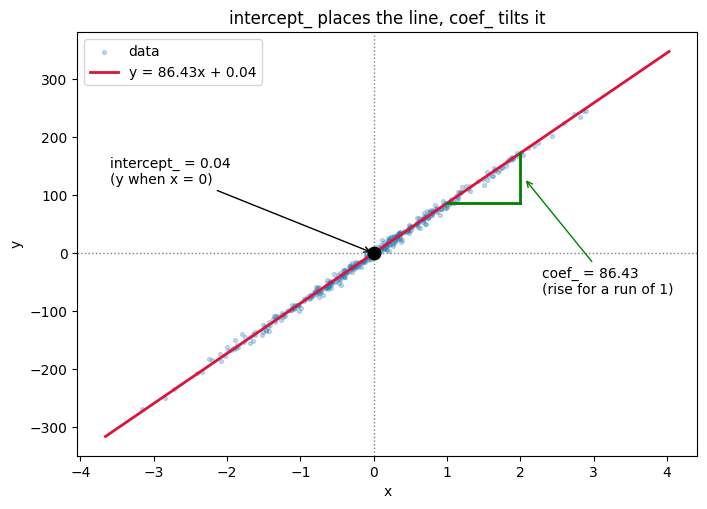

In [10]:
line_x = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
line_y = regressor.predict(line_x)

plt.figure(figsize=(8, 5.5))
plt.scatter(x[:400], y[:400], s=8, alpha=0.25, label="data")
plt.plot(line_x, line_y, color="crimson", lw=2, label=f"y = {m:.2f}x + {c:.2f}")

# --- intercept: where the line crosses x = 0 ---
plt.axvline(0, color="grey", ls=":", lw=1)
plt.axhline(0, color="grey", ls=":", lw=1)
plt.scatter([0], [c], color="black", zorder=5, s=80)
plt.annotate(f"intercept_ = {c:.2f}\n(y when x = 0)",
             xy=(0, c), xytext=(-3.6, 120),
             arrowprops=dict(arrowstyle="->", color="black"))

# --- coefficient: the rise over a run of 1 ---
plt.plot([1, 2], [m*1 + c, m*1 + c], color="green", lw=2)   # run  = 1
plt.plot([2, 2], [m*1 + c, m*2 + c], color="green", lw=2)   # rise = coef_
plt.annotate(f"coef_ = {m:.2f}\n(rise for a run of 1)",
             xy=(2.05, m*1.5 + c), xytext=(2.3, -70),
             arrowprops=dict(arrowstyle="->", color="green"))

plt.xlabel("x"); plt.ylabel("y"); plt.legend(loc="upper left")
plt.title("intercept_ places the line, coef_ tilts it")
plt.show()

## 11. What each knob actually does

Turn one knob at a time and watch what changes.

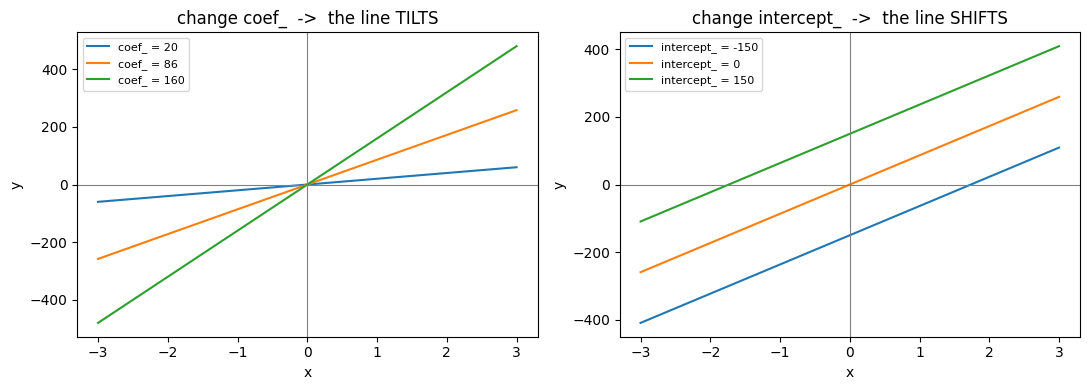

In [11]:
xs = np.linspace(-3, 3, 50)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for slope in [20, 86, 160]:                      # intercept fixed
    ax[0].plot(xs, slope * xs + c, label=f"coef_ = {slope}")
ax[0].set_title("change coef_  ->  the line TILTS")

for shift in [-150, 0, 150]:                     # slope fixed
    ax[1].plot(xs, m * xs + shift, label=f"intercept_ = {shift}")
ax[1].set_title("change intercept_  ->  the line SHIFTS")

for a in ax:
    a.axhline(0, color="grey", lw=0.8)
    a.axvline(0, color="grey", lw=0.8)
    a.set_xlabel("x"); a.set_ylabel("y"); a.legend(fontsize=8)

plt.tight_layout(); plt.show()

Left: all three lines cross the axis at the same place, but lean differently.
That is the **coefficient**.

Right: all three lines lean the same, but sit at different heights.
That is the **intercept**.

`fit()` picked the one pair of knob settings that puts the line closest to our dots.

## 12. Predict on all 10000 rows

The same formula, applied to the whole dataset this time, so we can draw predictions
next to the real values.

In [12]:
y_pred = regressor.predict(x)
y_pred

array([ 130.08472986,  -44.53477921, -167.86426893, ..., -142.37365931,
         13.8749839 ,  -72.20838078], shape=(10000,))

## 13. Actual vs predicted

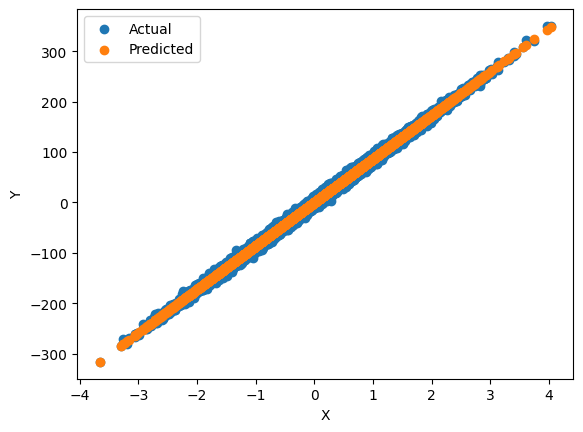

In [13]:
plt.scatter(x,y,label="Actual")
plt.scatter(x,y_pred,label="Predicted")
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

Blue = the real, noisy dots. Orange = the predictions.

The orange points form a perfectly straight line. They have to — every one of them
came out of `86.43 * x + 0.04`. A model's predictions can never be more crooked than
the model itself.

The blue cloud sitting evenly around the orange line is the sign of a good fit. If
the blue dots curved away from the orange line, a straight line would be the wrong
model for this data.

---

# 14. How does `fit()` actually find these two numbers?

**Short answer: it does not try values one by one. It solves one equation, once.**

Trying many candidate lines and keeping the best is a **search**. That is a real
method — it is called gradient descent, and it is what neural networks use. Linear
regression does not need it.

For a straight line there is an exact formula for the answer. sklearn calls that
formula and is finished. No loop, no "getting closer", no stopping rule.

Both paths exist in machine learning, so it is worth knowing which one you are on:

```mermaid
flowchart TD
    A["training rows"] --> B{"is there a formula<br/>for the best answer?"}
    B -->|"yes - straight line"| C["Normal equation / SVD<br/>one shot, exact"]
    B -->|"no - logistic, SVM,<br/>neural nets"| D["Gradient descent<br/>many small steps"]
    C --> E["coef_ and intercept_"]
    D --> E
    style C fill:#2f9e6f,color:#fff
    style D fill:#b3781f,color:#fff
```

Below: what "best" means (14.1), why a formula is possible at all (14.2), the formula
itself, what sklearn really runs (14.4), and the iterative version you were imagining
(14.5) — written out and run, so you can watch it land on the same numbers.

## 14.1 First — what does "best" mean?

Before anything can be found, "best" has to be a number.

Take a line, run it over the training rows, and measure the **vertical gap** between
each real dot and the line. Square each gap, then average them.

```text
gap for one row = actual y  -  predicted y
cost            = average of (gap)^2        <- one number for the whole line
```

This is the **cost** (also called loss, or MSE — mean squared error).
Low cost = good line.

Why square the gaps?

1. It removes the sign. A gap of `-10` is as bad as `+10`. Without squaring, a line
   that is 100 too high on one row and 100 too low on the next would score zero.
2. It punishes big misses much harder than small ones. Off by 10 is 100x worse than
   off by 1, not 10x worse.
3. It makes the maths smooth, which is what lets a formula exist at all. The plain
   absolute value has a sharp corner and gives no clean formula.

**"The best line" now simply means: the pair `(m, c)` with the smallest cost.** That is
the whole definition. Let's check that sklearn's pair really is the smallest.

In [14]:
def cost(m_try, c_try):
    # average squared vertical gap over the 8000 training rows
    predicted = m_try * X_train.ravel() + c_try
    return ((y_train - predicted) ** 2).mean()

print("sklearn's line       m=86.43, c=0.04 :", round(cost(m, c), 2))
print("too flat             m=50.00, c=0.04 :", round(cost(50, c), 2))
print("too steep            m=120.0, c=0.04 :", round(cost(120, c), 2))
print("right tilt, too high m=86.43, c=100  :", round(cost(m, 100), 2))

sklearn's line       m=86.43, c=0.04 : 25.6
too flat             m=50.00, c=0.04 : 1350.4
too steep            m=120.0, c=0.04 : 1149.99
right tilt, too high m=86.43, c=100  : 10017.15


sklearn's pair wins. Every other pair is worse.

And its cost is not zero only because we deliberately added `noise=5` to the data.
Noise of 5, squared, is 25 — so the model is as close to perfect as this data allows.
That leftover is the part no straight line could ever have captured.

## 14.2 The shape of the cost — this is the whole trick

Now plot the cost while sliding one knob at a time. This picture is the reason no
searching is needed.

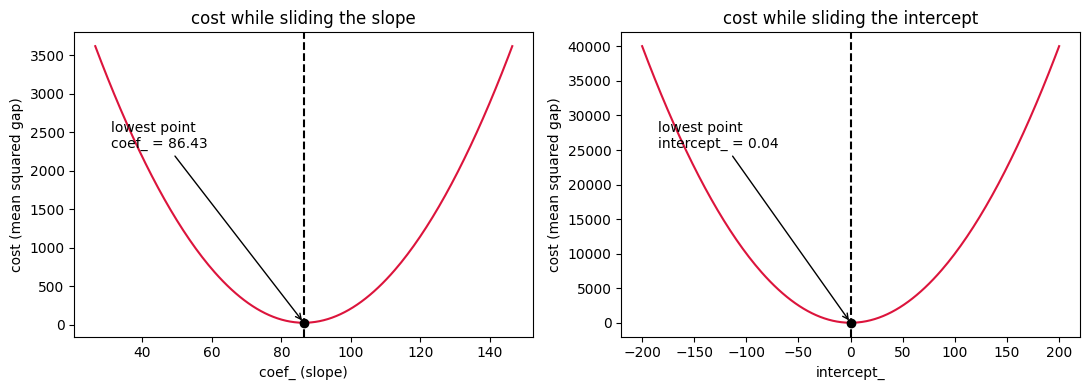

In [15]:
slopes     = np.linspace(m - 60, m + 60, 200)
intercepts = np.linspace(c - 200, c + 200, 200)
best = cost(m, c)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(slopes, [cost(s, c) for s in slopes], color="crimson")
ax[0].axvline(m, ls="--", color="black")
ax[0].scatter([m], [best], color="black", zorder=5)
ax[0].annotate(f"lowest point\ncoef_ = {m:.2f}", xy=(m, best), xytext=(0.08, 0.62),
               textcoords="axes fraction", arrowprops=dict(arrowstyle="->"))
ax[0].set_title("cost while sliding the slope")
ax[0].set_xlabel("coef_ (slope)")

ax[1].plot(intercepts, [cost(m, i) for i in intercepts], color="crimson")
ax[1].axvline(c, ls="--", color="black")
ax[1].scatter([c], [best], color="black", zorder=5)
ax[1].annotate(f"lowest point\nintercept_ = {c:.2f}", xy=(c, best), xytext=(0.08, 0.62),
               textcoords="axes fraction", arrowprops=dict(arrowstyle="->"))
ax[1].set_title("cost while sliding the intercept")
ax[1].set_xlabel("intercept_")

for a in ax:
    a.set_ylabel("cost (mean squared gap)")
plt.tight_layout(); plt.show()

Both curves are **parabolas** — clean bowls. Not a bumpy landscape with many dips.
One bottom, and that bottom is the answer.

Two facts about a bowl:

1. It has exactly **one** lowest point. So the best line is unique — no risk of
   settling for a good-but-not-best answer.
2. At that lowest point the curve is **flat**. Its slope is zero.

Fact 2 is what removes the search. Instead of hunting for the bottom, you write down
"the slope of the cost curve is zero" as an equation and solve it, like school algebra.

Two knobs → two equations → two unknowns. Solving them gives:

$$m = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sum (x - \bar{x})^2}
\qquad\qquad
c = \bar{y} - m\,\bar{x}$$

In plain English:

| Part | What it measures |
|---|---|
| top of `m` | do `x` and `y` move together, and how strongly? (**covariance**) |
| bottom of `m` | how spread out is `x` on its own? (**variance**) |
| `m` overall | "how much they move together" ÷ "how much x moves" |
| `c` | slides the line so it passes through the average point $(\bar{x}, \bar{y})$ |

That last one is worth keeping: **every least-squares line passes through the mean of
the data.** Not a coincidence — it falls straight out of the second equation.

Let's run those two formulas ourselves.

In [16]:
xt = X_train.ravel()
yt = y_train

m_hand = ((xt - xt.mean()) * (yt - yt.mean())).sum() / ((xt - xt.mean()) ** 2).sum()
c_hand = yt.mean() - m_hand * xt.mean()

print("my formula  ->  m =", m_hand, " c =", c_hand)
print("sklearn     ->  m =", m,      " c =", c)
print("same? ->", np.allclose([m_hand, c_hand], [m, c]))

my formula  ->  m = 86.43440685172207  c = 0.042274723015908844
sklearn     ->  m = 86.43440685172204  c = 0.042274723015908955
same? -> True


Same numbers. Two lines of arithmetic over the 8000 rows — no repetition, no tuning,
no starting guess.

## 14.3 With more than one column — the matrix version

Those two formulas only work for a single input column. With many columns you cannot
write `m` on its own, because the columns influence each other. The same idea in matrix
form is the **Normal Equation**:

$$\beta = (X^{T}X)^{-1} X^{T} y$$

`β` is the full list of answers: every coefficient **plus** the intercept. To make the
intercept fall out of it, glue a column of **1s** onto `X`. That fake column's
"coefficient" is the intercept, because it is multiplied by 1 on every row.

```text
X            X with the 1s column
[ 1.24 ]     [ 1   1.24 ]      ->   beta = [ intercept , coef ]
[ 0.98 ]     [ 1   0.98 ]
[-1.59 ]     [ 1  -1.59 ]
```

In [17]:
X_b = np.c_[np.ones(len(X_train)), X_train]        # glue the column of 1s in front

beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_train

print("beta    ->", beta)                # [intercept, coefficient]
print("sklearn -> [", c, ",", m, "]")
print("same? ->", np.allclose(beta, [c, m]))

beta    -> [4.22747230e-02 8.64344069e+01]
sklearn -> [ 0.042274723015908955 , 86.43440685172204 ]
same? -> True


One multiplication, one inversion, done. No iteration anywhere.

The cost of this is driven by the **number of columns**, not the number of rows —
inverting $X^{T}X$ is roughly $p^3$ work, where `p` is the column count. With 1 or 20
columns that is instant. Remember this: it is the whole reason gradient descent exists
(14.5).

## 14.4 What sklearn *actually* runs

Not the line we just wrote. Inverting $X^{T}X$ literally is numerically risky — if two
columns are near-duplicates, the matrix is nearly un-invertible and the answer explodes.

So sklearn hands the problem to LAPACK through `scipy.linalg.lstsq`, which solves it
with an **SVD** (singular value decomposition). Same answer, no inverse ever formed.

The real path through `sklearn/linear_model/_base.py`:

| Step | What happens | Where |
|---|---|---|
| 1 | subtract the mean from `X` and from `y` (centring) | `_preprocess_data(...)`, line ~702 |
| 2 | solve the centred problem for the slopes | `linalg.lstsq(X, y)` → `coef_`, line ~752 |
| 3 | put the intercept back | `_set_intercept(...)`, line ~330 |

Step 3 is literally this line of sklearn's source:

```python
self.intercept_ = y_offset - X_offset @ self.coef_
```

which is exactly our $c = \bar{y} - m\bar{x}$. And the centring in step 1 is *why* the
intercept is so cheap to recover: once both columns are centred, the best line has to
pass through `(0, 0)`, so only the slope is left to solve for.

Two side effects prove an SVD really ran — the fitted object carries `rank_` and
`singular_`, which only an SVD produces.

Which solver you get depends on the input:

| Input | Solver | Iterative? |
|---|---|---|
| normal dense array (**our case**) | `scipy.linalg.lstsq` → SVD | no |
| sparse matrix | `scipy.sparse.linalg.lsqr` | yes |
| `positive=True` | `scipy.optimize.nnls` | yes |

In [18]:
print("rank_     :", regressor.rank_)       # how many columns were actually independent
print("singular_ :", regressor.singular_)   # the SVD's singular values

# reproduce sklearn's own three steps by hand
X_off, y_off = X_train.mean(axis=0), y_train.mean()                            # 1. centre
coef_svd = np.linalg.lstsq(X_train - X_off, y_train - y_off, rcond=None)[0]    # 2. lstsq
intercept_svd = y_off - X_off @ coef_svd                                       # 3. intercept back

print("\nby sklearn's own route ->", coef_svd, intercept_svd)
print("same? ->", np.allclose([coef_svd[0], intercept_svd], [m, c]))

rank_     : 1
singular_ : [89.35213963]

by sklearn's own route -> [86.43440685] 0.042274723015908955
same? -> True


`rank_` is 1 because there is one usable column, and `singular_` has one entry for the
same reason.

## 14.5 The iterative way — gradient descent

This is the method you were describing, and it is real. It is just not what
`LinearRegression` uses.

Gradient descent does not know the formula. It starts at a guess — say `m=0, c=0` — and
walks downhill on the bowl from 14.2:

```text
repeat:
    1. predict with the current m and c
    2. measure the error
    3. work out which way is downhill   (the gradient)
    4. take a small step that way       (step size = learning rate)
```

"Downhill" is calculus, but for this cost it is two short lines:

```text
downhill for m  =  2 * average( error * x )
downhill for c  =  2 * average( error )
```

Watch it walk to the answer we already have.

In [19]:
m_gd, c_gd = 0.0, 0.0          # start at a deliberately wrong guess
learning_rate = 0.1
path = []

for step in range(60):
    predicted = m_gd * xt + c_gd
    error = predicted - yt

    down_m = 2 * (error * xt).mean()      # which way is downhill for the slope
    down_c = 2 * error.mean()             # which way is downhill for the intercept

    m_gd -= learning_rate * down_m        # take one small step
    c_gd -= learning_rate * down_c
    path.append((m_gd, c_gd, (error ** 2).mean()))

    if step in (0, 1, 2, 5, 10, 20, 40, 59):
        print(f"step {step:>2}   m = {m_gd:8.4f}   c = {c_gd:7.4f}   cost = {(error ** 2).mean():12.2f}")

print("\ngradient descent ->", round(m_gd, 6), round(c_gd, 6))
print("the formula      ->", round(m, 6), round(c, 6))

step  0   m =  17.2522   c =  0.0764   cost =      7481.53
step  1   m =  31.0608   c =  0.1239   cost =      4802.15
step  2   m =  42.1132   c =  0.1511   cost =      3085.65
step  5   m =  63.7075   c =  0.1649   cost =       830.20
step 10   m =  78.9683   c =  0.1190   cost =       112.44
step 20   m =  85.6286   c =  0.0584   cost =        26.61
step 40   m =  86.4250   c =  0.0426   cost =        25.60
step 59   m =  86.4343   c =  0.0423   cost =        25.60

gradient descent -> 86.43427 0.042283
the formula      -> 86.434407 0.042275


It gets there. Big jumps at first, because the bowl is steep far from the bottom, then
smaller and smaller steps as the ground flattens. That slowdown is automatic — the
gradient itself shrinks near the bottom.

Drawn on the bowl, both knobs at once. Darker blue = lower cost:

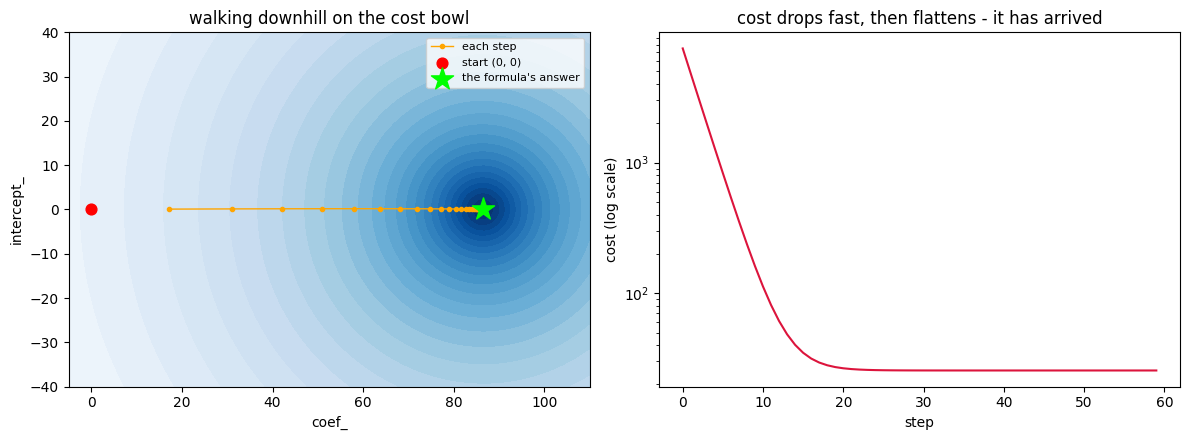

In [20]:
path = np.array(path)

M, C = np.meshgrid(np.linspace(-5, 110, 80), np.linspace(-40, 40, 80))
Z = np.array([[cost(mm, cc) for mm, cc in zip(row_m, row_c)] for row_m, row_c in zip(M, C)])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].contourf(M, C, np.log10(Z), levels=30, cmap="Blues_r")
ax[0].plot(path[:, 0], path[:, 1], "o-", color="orange", ms=3, lw=1, label="each step")
ax[0].scatter([0], [0], color="red", s=60, zorder=5, label="start (0, 0)")
ax[0].scatter([m], [c], marker="*", color="lime", s=280, zorder=5, label="the formula's answer")
ax[0].set_xlabel("coef_"); ax[0].set_ylabel("intercept_")
ax[0].set_title("walking downhill on the cost bowl"); ax[0].legend(fontsize=8)

ax[1].plot(path[:, 2], color="crimson")
ax[1].set_yscale("log")
ax[1].set_xlabel("step"); ax[1].set_ylabel("cost (log scale)")
ax[1].set_title("cost drops fast, then flattens - it has arrived")

plt.tight_layout(); plt.show()

The orange track walks straight into the green star. Same destination — 60 passes over
the data instead of one formula.

The track is almost a flat line because the **intercept was already nearly right at
step 0**. This data is centred on zero, so `c` had almost nowhere to travel and all the
work was in the slope. On data that is not centred — house prices, salaries — the track
would curve down into the bowl from both directions.

**So why does gradient descent exist at all?**

1. **Columns.** The direct formula costs about $p^3$ in the column count. At 50,000
   columns that is fatal. Gradient descent never builds $X^{T}X$; one step is just one
   pass over the data.
2. **Memory.** If the data does not fit in RAM you cannot form $X^{T}X$ at all, but you
   can still feed batches through gradient descent (`SGDRegressor.partial_fit`).
3. **Most models have no formula.** Logistic regression, SVMs, neural networks — their
   cost surface is not a clean parabola, so there is nothing to solve exactly.
   Gradient descent is the only general tool.

Linear regression is the rare lucky case where the exact answer is available. Worth
noticing: **almost every other model in this course is trained by walking downhill,
not by solving.**

| | Normal equation / SVD | Gradient descent |
|---|---|---|
| sklearn class | `LinearRegression` | `SGDRegressor`, and most others |
| how it finds the answer | one formula | many small steps |
| passes over the data | 1 | tens to thousands |
| knobs to tune | none | learning rate, number of steps |
| exact? | yes | close enough, when tuned well |
| breaks when | too many columns, or no RAM | rarely — it just gets slow |
| works for other models? | no, straight lines only | yes, nearly all of them |

Your instinct was not wrong. It was one model early.

### 💡 Engineering Extension — when the direct formula has no answer

*Recommended Extension - Not part of instructor curriculum*

The formula assumes $X^{T}X$ can be inverted. Hand it a duplicated column and it
cannot: if column B is a copy of column A, then `2A + 0B`, `0A + 2B` and `1A + 1B` all
give identical predictions. There are infinitely many equally best answers, so there is
no single one to return.

The SVD does not crash on this. It returns the smallest of those equally-good answers
and drops `rank_` below the number of columns. That is what `rank_` is for — it tells
you how many of your columns actually carried independent information.

In [21]:
X_dup = np.c_[X_train, X_train]      # column 2 is an exact copy of column 1

dup_model = LinearRegression().fit(X_dup, y_train)
print("coefficients :", dup_model.coef_, "-> they add up to", dup_model.coef_.sum())
print("rank_        :", dup_model.rank_, "of", X_dup.shape[1], "columns")

# meanwhile, the raw normal equation on the same data
gram = np.c_[np.ones(len(X_dup)), X_dup]
gram = gram.T @ gram
print("\ncondition number of X.T @ X :", f"{np.linalg.cond(gram):.3e}", " (huge = not invertible)")
try:
    np.linalg.inv(gram)
    print("np.linalg.inv returned something, but at this condition number it is meaningless")
except np.linalg.LinAlgError as e:
    print("np.linalg.inv says:", e)

coefficients : [43.21720343 43.21720343] -> they add up to 86.43440685172203
rank_        : 1 of 2 columns

condition number of X.T @ X : 2.495e+32  (huge = not invertible)
np.linalg.inv says: Singular matrix


Two coefficients of about `43.2` each, adding up to our original `86.43` — the model
split the credit evenly instead of picking a winner. `rank_` is `1`, not `2`, and that
is the warning sign.

This is exactly the problem **Ridge regression** was invented to fix, and it is why
duplicated or near-duplicated features are worth removing before fitting.

## Takeaway

If you remember only one thing: **`fit()` squeezes thousands of rows into two
numbers, and `predict()` is nothing more than those two numbers in
`y = coef_ * x + intercept_`.**

| | Question it answers | Type | Value here |
|---|---|---|---|
| `coef_` | how steep is the line? | array, one per input column | `[86.43]` |
| `intercept_` | where does the line start? | single float | `0.04` |

With many columns the formula just gets longer, one coefficient each, still one
intercept:

```text
y = c0*x0 + c1*x1 + c2*x2 + ... + intercept
```

**And how those two numbers are found:** not by trying candidates one at a time. The
cost curve is a bowl, the bottom of a bowl is flat, so "flat" gets written as an
equation and solved in one shot — `scipy.linalg.lstsq` under the hood. Gradient
descent, the walking-downhill method, reaches the same place and is what nearly every
*other* model has to use.